# Marketing A/B Test — Campaign Effectiveness Analysis

## Project Overview

This project analyses the effectiveness of a digital advertising campaign using an A/B testing approach.

The main objective is to determine whether users exposed to the advertising campaign have a higher conversion rate than users in the control group, who were shown a public service announcement (PSA).

### Business Question

**Does showing the advertisement increase the conversion rate compared with the PSA control group?**

### Project Stages

1. Data Exploration & Cleaning
2. Campaign Performance
3. Hypothesis Testing
4. Tableau Dashboard & Business Recommendation

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 — How many rows and columns?

In [14]:
# Load the dataset

df = pd.read_csv("../data/marketing_AB.csv")

df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


Step 2 — How many rows and columns?

In [15]:
# Check the number of rows and columns

df.shape

(588101, 7)

Step 3 — Inspect the data types:

In [16]:
# Inspect the dataset structure and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB


What we learned

Your dataset has 588,101 rows and all 7 columns have 588,101 non-null values.

Column	Data type	What it tells us
Unnamed: 0	int64	Technical index — not needed for analysis
user id	int64	User identifier
test group	str	Ad / PSA group
converted	bool	True / False conversion
total ads	int64	Number of ads seen
most ads day	str	Day with most ads
most ads hour	int64	Hour with most ads

Most importantly:

There are no missing values because every column has 588,101 non-null entries. ✅

The data types also look appropriate for the analysis, so we don't need to convert anything yet. The one thing we need to clean is the technical Unnamed: 0 column, which the project brief tells us to remove when applicable.

Step 4 — Check for missing values

In [17]:
# Check for missing values

df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

The result confirms that there are no missing values anywhere in the dataset.

We can note this in our analysis:

Data quality finding: All 588,101 observations have complete values across all seven columns, with no missing data.

Step 5 — checking duplicated user IDs.

In [18]:
# Check for duplicated user IDs

df["user id"].duplicated().sum()

np.int64(0)

The data-quality checks so far are looking good:

✅ 588,101 users
✅ 7 columns
✅ No missing values
✅ No duplicated user IDs
🔎 One technical column (Unnamed: 0) to remove later

Step 6 — Check the experimental groups

In [19]:
# Check the unique values in the test group column

df["test group"].unique()

<StringArray>
['ad', 'psa']
Length: 2, dtype: str

the dataset has two experimental groups:

ad → advertising/treatment group
psa → control group

This matches the project brief's definition of the experimental variable.

Step 7 — Check the conversion values:

In [20]:
# Check the unique values in the converted column

df["converted"].unique()

array([False,  True])

tre results are: [False, True]
So converted contains exactly the two expected values:

False → user did not convert
True → user converted/purchased

Step 8 — Remove the technical index:

In [21]:
# Remove the technical index column

df = df.drop(columns=["Unnamed: 0"])

df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [22]:
# Check the cleaned dataset dimensions

df.shape

(588101, 6)

So after removing the technical Unnamed: 0 column, we still have:

588,101 users
6 useful analytical columns

And the remaining columns are exactly the ones we need for the project.

The brief's next requirement is to answer the basic business questions: total users, users in each group, overall conversion rate, and average ads seen per user.

Step 9 — Question 5: How many users?

## 1.1 Basic Dataset Metrics

We now calculate the main descriptive metrics required for the initial data exploration.

In [27]:
# Question 5: How many users are included in the dataset?

total_users = df["user id"].nunique()

total_users

588101

Step 10 — Question 6: How many users are in each group?

In [28]:
# Question 6: Number of users in each experimental group

group_counts = df["test group"].value_counts()

group_counts

test group
ad     564577
psa     23524
Name: count, dtype: int64

Step 11 — Question 7: Overall conversion rate:

In [29]:
# Question 7: Overall conversion rate

overall_conversion_rate = df["converted"].mean() * 100

overall_conversion_rate

np.float64(2.523886203220195)

You got: 2.523886203220195

So the overall conversion rate is approximately: 2.52%

In other words, about 2.52% of all users converted.

Step 12 — Question 8: Average number of advertisements seen:

In [30]:
# Question 8: Average number of advertisements seen per user

average_ads_per_user = df["total ads"].mean()

average_ads_per_user

np.float64(24.82087600599217)

So we can report:

The average user saw approximately 24.82 advertisements.

🎯 Step 1 — Basic metrics completed

We now have all four required answers:

Question	Result
5. Total users	588,101
6. Ad users	564,577
6. PSA users	23,524
7. Overall conversion rate	2.52%
8. Average ads per user	24.82


Next: Required Visualizations:

👥 Number of users by experimental group
📈 Conversion rate by experimental group
📊 Distribution of total advertisements seen per user

Visualization 1 — Users by experimental group

## 1.2 Exploratory Data Visualizations

### Users by Experimental Group

This chart shows the number of users assigned to each experimental group.

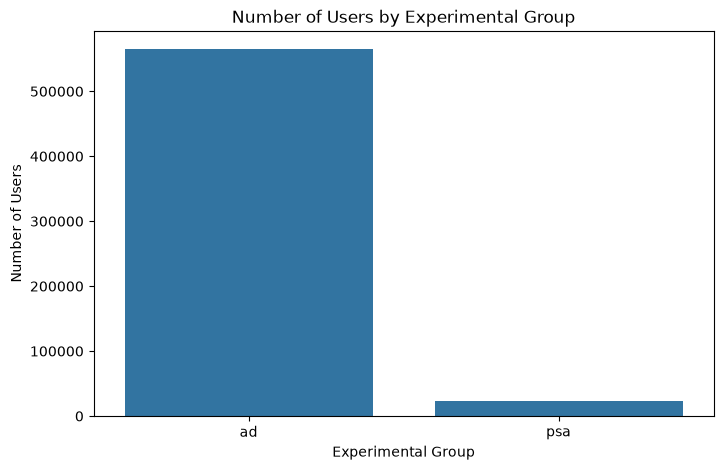

In [31]:
# Number of users by experimental group

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="test group")

plt.title("Number of Users by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Number of Users")

plt.show()

Visualization 2 — Conversion Rate by Experimental Group:

### Conversion Rate by Experimental Group

This chart compares the percentage of users who converted in the Ad and PSA groups.

In [32]:
# Calculate conversion rate by experimental group

conversion_by_group = df.groupby("test group")["converted"].mean() * 100

conversion_by_group

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64

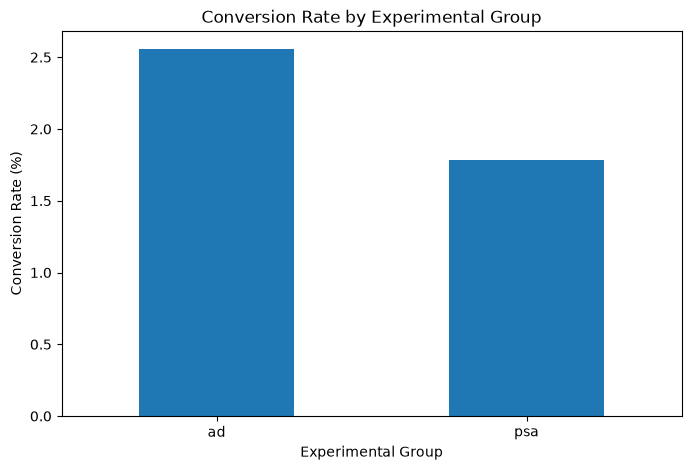

In [33]:
# Plot conversion rate by experimental group

plt.figure(figsize=(8, 5))

conversion_by_group.plot(kind="bar")

plt.title("Conversion Rate by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)

plt.show()

What we found
Experimental group	Conversion rate
Ad	2.55%
PSA	1.79%

So, descriptively, the Ad group has the higher conversion rate.

The observed difference is approximately:

2.55% − 1.79% = 0.77 percentage points

Visualization 3 — Distribution of Total Ads:

### Distribution of Total Advertisements Seen

This histogram shows how the number of advertisements seen by users is distributed across the dataset.

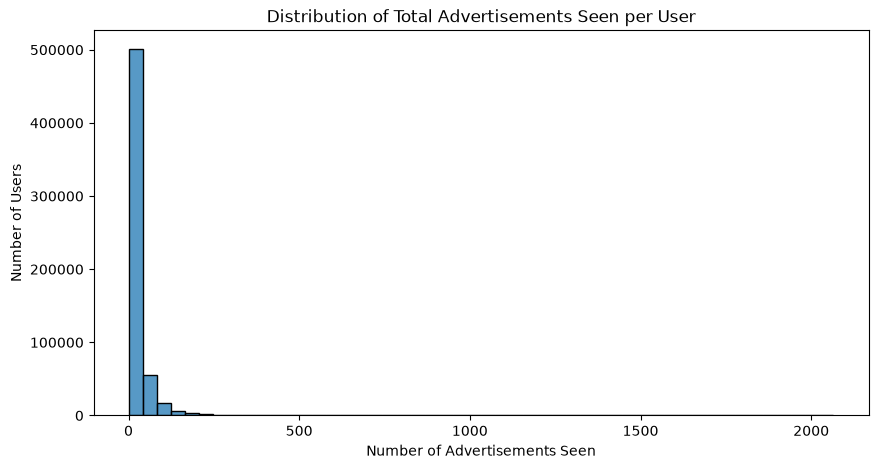

In [34]:
# Distribution of total advertisements seen per user

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="total ads", bins=50)

plt.title("Distribution of Total Advertisements Seen per User")
plt.xlabel("Number of Advertisements Seen")
plt.ylabel("Number of Users")

plt.show()

## 2. Campaign Performance

The PSA group is treated as the control group, while the Ad group is treated as the test/treatment group.

We compare the two groups using user counts, conversions, conversion rates, conversion rate difference, and relative improvement.

Next: Step 2 — Campaign Performance

Now we're moving from exploration to the actual business question.

The brief asks us to compare the Ad group against the PSA control group using:

Number of users
Number of conversions
Conversion rate
Conversion-rate difference
Relative improvement

We'll calculate all of these in one clean summary table, which will also make the analysis easier to use later in Tableau.

In [35]:
# Calculate campaign performance metrics

performance = df.groupby("test group").agg(
    users=("user id", "nunique"),
    conversions=("converted", "sum")
)

performance["conversion_rate"] = (
    performance["conversions"] / performance["users"] * 100
)

performance

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,2.554656
psa,23524,420,1.785411


In [36]:
# Calculate conversion rate difference and relative improvement

ad_rate = performance.loc["ad", "conversion_rate"]
psa_rate = performance.loc["psa", "conversion_rate"]

conversion_rate_difference = ad_rate - psa_rate

relative_improvement = (
    (ad_rate - psa_rate) / psa_rate
) * 100

print(f"Conversion rate difference: {conversion_rate_difference:.4f} percentage points")
print(f"Relative improvement: {relative_improvement:.2f}%")

Conversion rate difference: 0.7692 percentage points
Relative improvement: 43.09%


### Step 2 — Business Questions

**9. Which group has the higher conversion rate?**

The Ad group has the higher conversion rate, with a conversion rate of 2.55%, compared with 1.79% for the PSA group.

**10. How large is the observed difference?**

The conversion rate difference is 0.77 percentage points. The Ad group shows a relative improvement of 43.09% compared with the PSA group.

**11. Based only on the descriptive results, does the campaign appear promising?**

Based on the descriptive results, the campaign appears promising. Users in the Ad group converted at a higher rate than users in the PSA control group. However, this observed difference does not by itself prove that the advertising campaign caused the improvement. Statistical hypothesis testing is required to determine whether the difference is statistically significant.

## 3. Hypothesis Testing

The objective of this test is to determine whether the observed difference in conversion rates between the Ad and PSA groups is statistically significant.

### Hypotheses

**Null hypothesis (H₀):** The conversion rate is the same in the Ad and PSA groups.

**Alternative hypothesis (H₁):** The conversion rate is different between the Ad and PSA groups.

### Significance Level

The significance level is set at:

**α = 0.05**

### Statistical Test

A two-proportion z-test is appropriate because we are comparing the conversion proportions of two independent experimental groups.

Next: Step 3 — Hypothesis Testing

This is the most important statistical part of the project.

We need to test:

H₀: The conversion rate is the same in the Ad and PSA groups.

H₁: The conversion rate is different between the Ad and PSA groups.

And  use a two-proportion z-test with:

α = 0.05.

In [37]:
from statsmodels.stats.proportion import proportions_ztest

# Number of conversions in each group
conversions = [
    performance.loc["ad", "conversions"],
    performance.loc["psa", "conversions"]
]

# Number of users in each group
users = [
    performance.loc["ad", "users"],
    performance.loc["psa", "users"]
]

# Two-proportion z-test
z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative="two-sided"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: 7.3701
P-value: 0.000000


You got:
Z-statistic: 7.3701
P-value: 0.000000

What does this mean?
Our significance level is:
α = 0.05

The p-value is effectively 0 (much smaller than 0.05).

Therefore:
p-value < α → Reject H₀
So we have statistically significant evidence that the conversion rates of the Ad and PSA groups are different.
And because the Ad group has the higher conversion rate (2.55% vs 1.79%), the evidence supports an improvement associated with the advertising treatment.

The observed difference in conversion rates is statistically significant, and the Ad group has a higher conversion rate than the PSA control group.

### Statistical Decision

The two-proportion z-test produced a z-statistic of **7.3701** and a p-value effectively equal to **0**.

Since the p-value is smaller than the significance level of α = 0.05, we **reject the null hypothesis (H₀)**.

There is statistically significant evidence that the conversion rate differs between the Ad and PSA groups.

The Ad group has the higher observed conversion rate (2.55% compared with 1.79%), suggesting that the advertising campaign is associated with a higher conversion rate than the PSA control group.

However, statistical significance should be considered separately from practical business importance. The observed improvement is approximately **0.77 percentage points**, or **43.09% relative to the PSA conversion rate**.

Calculate exact p-value:

In [38]:
# Display the p-value with more precision

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10e}")

Z-statistic: 7.3701
P-value: 1.7052807162e-13


In [39]:
# Final campaign performance summary

summary = performance.copy()

summary["conversion_rate"] = summary["conversion_rate"].round(4)

summary

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,2.5547
psa,23524,420,1.7854


In [40]:
# Export the cleaned dataset for Tableau

df.to_csv("../data/marketing_AB_clean.csv", index=False)

print("Clean dataset exported successfully.")

Clean dataset exported successfully.
